In [1]:
%matplotlib inline
import torch 
import matplotlib.pyplot as plt
from torch import nn 

class LinearRegModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1, 
                                                dtype=torch.float),
                                                requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1, 
                                             dtype=torch.float,
                                             requires_grad=True))

    #Foward defines the computation in the model
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias
        

torch.manual_seed(42)
## Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))

model_0=LinearRegModel()
# Check the nn.Parameter(s) within the nn.Module subclass we created
print(list(model_0.parameters()))
print(model_0.state_dict())


[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.1288], requires_grad=True)]
OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])


In [2]:
weight=0.7
bias=0.3

#create data
start=0
end=1
step=0.02 
X=torch.arange(start,end,step).unsqueeze(dim=1)
y=weight*X+bias 
print(X[:10])
print(y[:10])

tensor([[0.0000],
        [0.0200],
        [0.0400],
        [0.0600],
        [0.0800],
        [0.1000],
        [0.1200],
        [0.1400],
        [0.1600],
        [0.1800]])
tensor([[0.3000],
        [0.3140],
        [0.3280],
        [0.3420],
        [0.3560],
        [0.3700],
        [0.3840],
        [0.3980],
        [0.4120],
        [0.4260]])


split data into training and test sets 

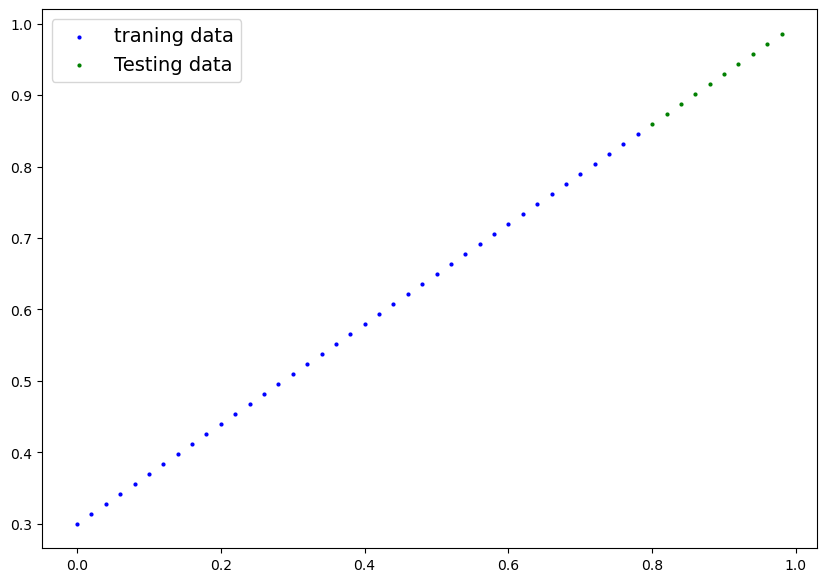

In [3]:
train_split=int(0.8*len(X))
X_train ,y_train=X[:train_split],y[:train_split]
X_test,y_test=X[train_split:],y[train_split:]


def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    fig,ax=plt.subplots(figsize=(10,7))
    ax.scatter(train_data,train_labels,c="b",s=4,label="traning data")
    ax.scatter(test_data,test_labels,c="g",s=4,label="Testing data")
    if predictions is not None:
        ax.scatter(test_data,predictions,c="r",s=4,label="predictions")

    ax.legend(prop={"size":14})
    plt.show()

plot_predictions()


In [4]:
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(model_0.parameters(),lr=0.01)

Epoch: 0 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882 
Epoch: 10 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882 
Epoch: 20 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882 
Epoch: 30 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882 
Epoch: 40 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882 
Epoch: 50 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882 
Epoch: 60 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882 
Epoch: 70 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882 
Epoch: 80 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882 
Epoch: 90 | MAE Train Loss: 0.008932482451200485 | MAE Test Loss: 0.005023092031478882 
The model learned the following values for weights and bias:
OrderedDict([('weights', tensor([0.6990])), ('bias', tensor(

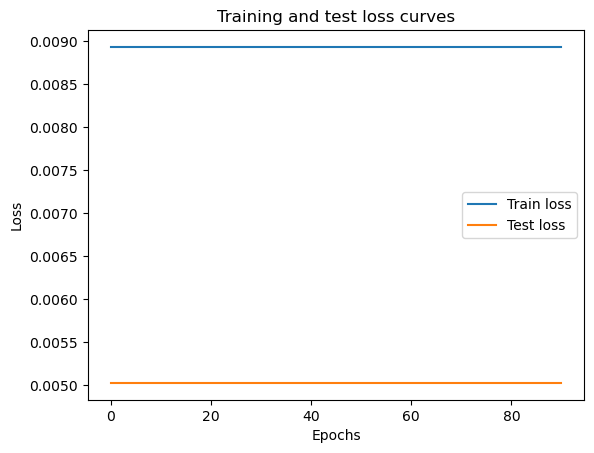

In [8]:
torch.manual_seed(42)

epochs=100

# device = "cuda" if torch.cuda.is_available() else "cpu"

# X_train=X_train.to(device)
# X_test = X_test.to(device)
# y_train = y_train.to(device)
# y_test = y_test.to(device)

train_loss_values=[]
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    model_0.train() # # Put model in training mode (this is the default state of a model)

    y_pred=model_0(X_train)
    loss=loss_fn(y_pred,y_train)

    optimizer.zero_grad()
    loss.backward()
    #progress the optimzer
    optimizer.step()

    # testing
    model_0.eval()
    with torch.inference_mode():
        # forward pass on test data
        test_pred = model_0(X_test)
        #calculate loss on the test data
        test_loss =loss_fn(test_pred,y_test.type(torch.float))

        #print out what's happening 
        if epoch % 10==0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE Train Loss: {loss} | MAE Test Loss: {test_loss} ")


# Plot the loss curves
plt.plot(epoch_count, train_loss_values, label="Train loss")
plt.plot(epoch_count, test_loss_values, label="Test loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

# Find our model's learned parameters
print("The model learned the following values for weights and bias:")
print(model_0.state_dict())
print("\nAnd the original values for weights and bias are:")
print(f"weights: {weight}, bias: {bias}")